# Othello-GPT world representations

This notebook uses the released Othello-GPT model, probes, and games to rerun results from [*Linear Latent World Models in Simple Transformers*](https://arxiv.org/abs/2310.07582). TDHook captures the board representation and applies the paper's inverse-map intervention across 50 games.

This completes the reproduction tracked in [issue #107](https://github.com/Xmaster6y/tdhook/issues/107).

## Setup

The model, probes, and game sequences are loaded from fixed public revisions. CUDA is used when available; CPU also works but takes longer.

In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
import types
import urllib.request
from pathlib import Path

import numpy as np
import torch
from huggingface_hub import hf_hub_download
from torch.nn import functional as F
from transformer_lens import HookedTransformer, HookedTransformerConfig

from tdhook.interventions import (
    EarlyStoppingConfig,
    InterventionObjective,
    InterventionSpec,
    OptimizerConfig,
    optimize_intervention,
)
from tdhook.session import HookSession
from tdhook.targets import Target

OTHELLO_REVISION = "f23bb5696cf30b93bd8af8a391ee33fc3aac417e"
HF_REVISION = "905ca1a68b9f7dff77adc56af1962e5f6fcac274"
CACHE = Path.home() / ".cache" / "tdhook" / "othello-reproduction"
CACHE.mkdir(parents=True, exist_ok=True)
BASE = f"https://raw.githubusercontent.com/likenneth/othello_world/{OTHELLO_REVISION}"
ASSETS = {
    "main_linear_probe.pth": f"{BASE}/mechanistic_interpretability/main_linear_probe.pth",
    "board_seqs_int_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_int_small.npy",
    "board_seqs_string_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_string_small.npy",
    "othello.py": f"{BASE}/data/othello.py",
}


def fetch(name: str) -> Path:
    path = CACHE / name
    if not path.exists():
        urllib.request.urlretrieve(ASSETS[name], path)
    return path


paths = {name: fetch(name) for name in ASSETS}
model_path = Path(
    hf_hub_download(
        repo_id="NeelNanda/Othello-GPT-Transformer-Lens",
        filename="synthetic_model.pth",
        revision=HF_REVISION,
        token=False,
    )
)
print({"othello_revision": OTHELLO_REVISION, "hf_revision": HF_REVISION})

{'othello_revision': 'f23bb5696cf30b93bd8af8a391ee33fc3aac417e', 'hf_revision': '905ca1a68b9f7dff77adc56af1962e5f6fcac274'}


In [2]:
# The released simulator imports `pgn` only for championship-data utilities.
# This reproduction uses synthetic games, so a stub keeps that unrelated optional dependency out.
sys.modules.setdefault("pgn", types.ModuleType("pgn"))
spec = importlib.util.spec_from_file_location("released_othello", paths["othello.py"])
othello = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(othello)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = HookedTransformerConfig(
    n_layers=8,
    d_model=512,
    d_head=64,
    n_heads=8,
    d_mlp=2048,
    d_vocab=61,
    n_ctx=59,
    act_fn="gelu",
    normalization_type="LNPre",
    device=str(device),
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
model.eval()
probe = torch.load(paths["main_linear_probe.pth"], map_location=device, weights_only=False)
games_int = torch.from_numpy(np.load(paths["board_seqs_int_small.npy"])[:100, :59].astype(np.int64)).to(device)
games_string = np.load(paths["board_seqs_string_small.npy"])[:100, :59]
print({"device": str(device), "games": tuple(games_int.shape), "probe": tuple(probe.shape)})

{'device': 'cuda', 'games': (100, 59), 'probe': (3, 512, 8, 8, 3)}


## Behavior and representation decoding

TDHook captures the layer-7 residual stream. The released linear probe decodes every square as empty, mine, or yours, and the model's top prediction is checked against legal moves.

In [3]:
states = []
for sequence in games_string:
    board = othello.OthelloBoardState()
    sequence_states = []
    for move in sequence.tolist():
        board.umpire(int(move))
        sequence_states.append(board.state.copy())
    states.append(np.stack(sequence_states))
states = torch.from_numpy(np.stack(states))
labels = torch.empty(states.shape, dtype=torch.long)
labels[states == 0], labels[states == -1], labels[states == 1] = 0, 1, 2
labels = labels.to(device)

residual_target = Target("blocks.6.hook_resid_post", "activation", -1, tuple(range(512)))
with torch.inference_mode():
    with HookSession(model) as session:
        captured = session.capture(residual_target)
        logits = model(games_int)
    probe_logits = torch.einsum("bpd,mdrco->mbprco", captured.values[-1], probe)
    probe_correct = probe_logits.argmax(-1) == labels.unsqueeze(0)

lo, hi = 5, 54
odd_accuracy = float(probe_correct[0, :, lo:hi:2].float().mean().cpu())
even_accuracy = float(probe_correct[1, :, lo + 1 : hi : 2].float().mean().cpu())
designated_accuracy = (odd_accuracy + even_accuracy) / 2

playable = [index for index in range(64) if index not in (27, 28, 35, 36)]
illegal = total = 0
predicted_tokens = logits.argmax(-1).cpu().numpy()
for game_index, sequence in enumerate(games_string):
    board = othello.OthelloBoardState()
    for position, move in enumerate(sequence.tolist()):
        board.umpire(int(move))
        if position < 58:
            token = int(predicted_tokens[game_index, position])
            predicted_square = -1 if token == 0 else playable[token - 1]
            illegal += int(predicted_square not in board.get_valid_moves())
            total += 1
legal_rate = 1 - illegal / total

paper_targets = {"designated_probe_accuracy": 0.995, "legal_move_rate": 0.999}
observed = {
    "odd_probe_accuracy": odd_accuracy,
    "even_probe_accuracy": even_accuracy,
    "designated_probe_accuracy": designated_accuracy,
    "legal_move_rate": legal_rate,
    "evaluated_next_move_positions": total,
}
tolerance = 0.005
print(json.dumps({"observed": observed, "paper_targets": paper_targets, "tolerance": tolerance}, indent=2))

{
  "observed": {
    "odd_probe_accuracy": 0.9927937388420105,
    "even_probe_accuracy": 0.9928125143051147,
    "designated_probe_accuracy": 0.9928031265735626,
    "legal_move_rate": 0.9993103448275862,
    "evaluated_next_move_positions": 5800
  },
  "paper_targets": {
    "designated_probe_accuracy": 0.995,
    "legal_move_rate": 0.999
  },
  "tolerance": 0.005
}


## One intervention

For one game, TDHook replaces a residual-stream activation and is compared with the authors' TransformerLens hook. We then optimize that activation with the released probe objective.

In [4]:
game = games_int[8:9, :51]
position, layer, row, column, scale = 50, 3, 7, 4, 4
direction = probe[0, :, row, column, 2] - probe[0, :, row, column, 1]
direction = direction / direction.norm()
position_target = Target(f"blocks.{layer}.hook_resid_post", "activation", -2, (position,))

with torch.inference_mode():
    with HookSession(model) as capture_session:
        activation = capture_session.capture(position_target)
        model(game)
    coefficient = (activation.values[-1] @ direction).unsqueeze(-1)
    replacement = activation.values[-1] - (scale + 1) * coefficient * direction
    with HookSession(model) as intervention_session:
        intervention_session.replace(position_target, replacement)
        tdhook_log_probs = model(game).log_softmax(-1)

    def reference_hook(residual, hook):
        coefficient = residual[0, position] @ direction
        residual[0, position] -= (scale + 1) * coefficient * direction

    reference_log_probs = model.run_with_hooks(
        game, fwd_hooks=[(f"blocks.{layer}.hook_resid_post", reference_hook)]
    ).log_softmax(-1)

max_abs_difference = float((tdhook_log_probs - reference_log_probs).abs().max().cpu())
parity_tolerance = 1e-5
print(
    {
        "max_abs_difference": max_abs_difference,
        "tolerance": parity_tolerance,
        "matches": max_abs_difference <= parity_tolerance,
    }
)
print(intervention_session.program)

probe_mode = 1 if position % 2 == 0 else 0
target_board = labels[8, position].clone()
target_board[row, column] = 1 if target_board[row, column] != 1 else 2


def probe_board_objective(_model_output, intervention):
    board_logits = torch.einsum("...d,drco->...rco", intervention, probe[probe_mode])
    desired = target_board.expand(*intervention.shape[:-1], 8, 8)
    probe_loss = F.cross_entropy(board_logits.flatten(0, -2), desired.flatten())
    return InterventionObjective(probe_loss, {"probe_cross_entropy": probe_loss})


optimized = optimize_intervention(
    model,
    (game,),
    InterventionSpec(
        position_target,
        probe_board_objective,
        "released linear-probe board cross-entropy",
        max_steps=300,
        optimizer=OptimizerConfig("adam", 5e-2),
        early_stopping=EarlyStoppingConfig(objective_threshold=0.05, min_delta=1e-5, patience=30),
        preservation_regularizer=lambda value, reference: 1e-4 * (value - reference).square().mean(),
    ),
    seed=44,
)
optimized_value = optimized.interventions[0].value
optimized_board = torch.einsum("...d,drco->...rco", optimized_value, probe[probe_mode]).argmax(-1)
optimized_matches = bool(torch.equal(optimized_board[0, 0], target_board))
optimization_artifact = optimized.to_dict()
print(json.dumps({"optimized_board_matches_target": optimized_matches, **optimization_artifact}, indent=2))

{'max_abs_difference': 0.0, 'tolerance': 1e-05, 'matches': True}
HookProgram(hooks=(HookSpec(module_path='blocks.3.hook_resid_post', operation='replace', direction='fwd', prepend=False, target=Target(module_path='blocks.3.hook_resid_post', kind='activation', feature_axis=-2, indices=(50,), parameter=None, output_path=(), occurrences=None), source=None),), stopped_at=None)


{
  "optimized_board_matches_target": true,
  "stages": [
    {
      "target": {
        "module_path": "blocks.3.hook_resid_post",
        "kind": "activation",
        "feature_axis": -2,
        "indices": [
          50
        ],
        "parameter": null,
        "output_path": [],
        "occurrences": null
      },
      "objective_name": "released linear-probe board cross-entropy",
      "optimizer": {
        "name": "adam",
        "learning_rate": 0.05,
        "kwargs": {}
      },
      "early_stopping": {
        "objective_threshold": 0.05,
        "min_delta": 1e-05,
        "patience": 30
      },
      "step_budget": 300,
      "steps_completed": 4,
      "model_pass_budget": 301,
      "model_passes": 5,
      "status": "converged",
      "history": [
        {
          "step": 0,
          "terms": {
            "loss": 0.26183658838272095,
            "probe_cross_entropy": 0.26183658838272095,
            "preservation": 0.0
          }
        },
        {
  

## Figure 4 intervention sweep

The released Figure 4 experiment maps option 2's activation toward the board decoded for option 1, then measures how similar their move logits become. We repeat it across 50 games and all eight layers, with sham, wrong-layer, and randomized-probe comparisons.

{
  "behavior_and_probe": {
    "layer_probe_accuracy": [
      0.912318229675293,
      0.9500318765640259,
      0.9718590378761292,
      0.9822608232498169,
      0.9889381527900696,
      0.9920504093170166,
      0.9925255179405212,
      0.9920440316200256
    ],
    "deep_layer_6_to_8_probe_accuracy": 0.9922066529591879,
    "legal_move_rate": 0.9993103448275862,
    "evaluated_next_move_positions": 5800,
    "paper_targets": {
      "deep_layer_probe_accuracy": 0.995,
      "legal_move_rate": 0.999
    },
    "absolute_tolerance": 0.005
  },
  "ordering": {
    "early_game_max_length": 20,
    "middle_layers": [
      3,
      4,
      5
    ],
    "late_layers": [
      7,
      8
    ],
    "mean_paired_gain_difference": 0.13022883656124273,
    "bootstrap_95_ci": [
      0.1249120662804693,
      0.13612584023599822
    ]
  },
  "tdhook_reference_parity_max_abs_difference": 0.0
}


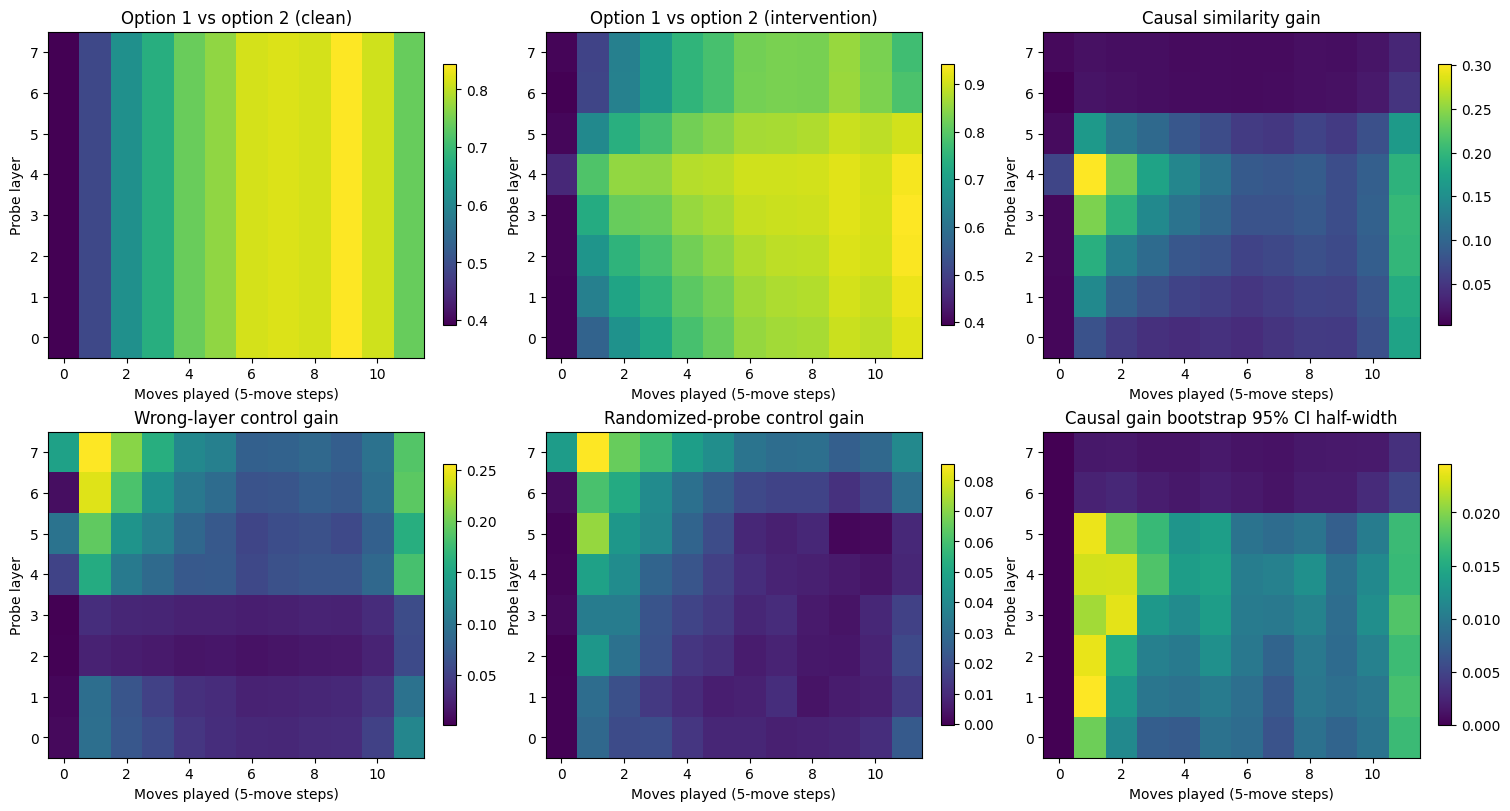

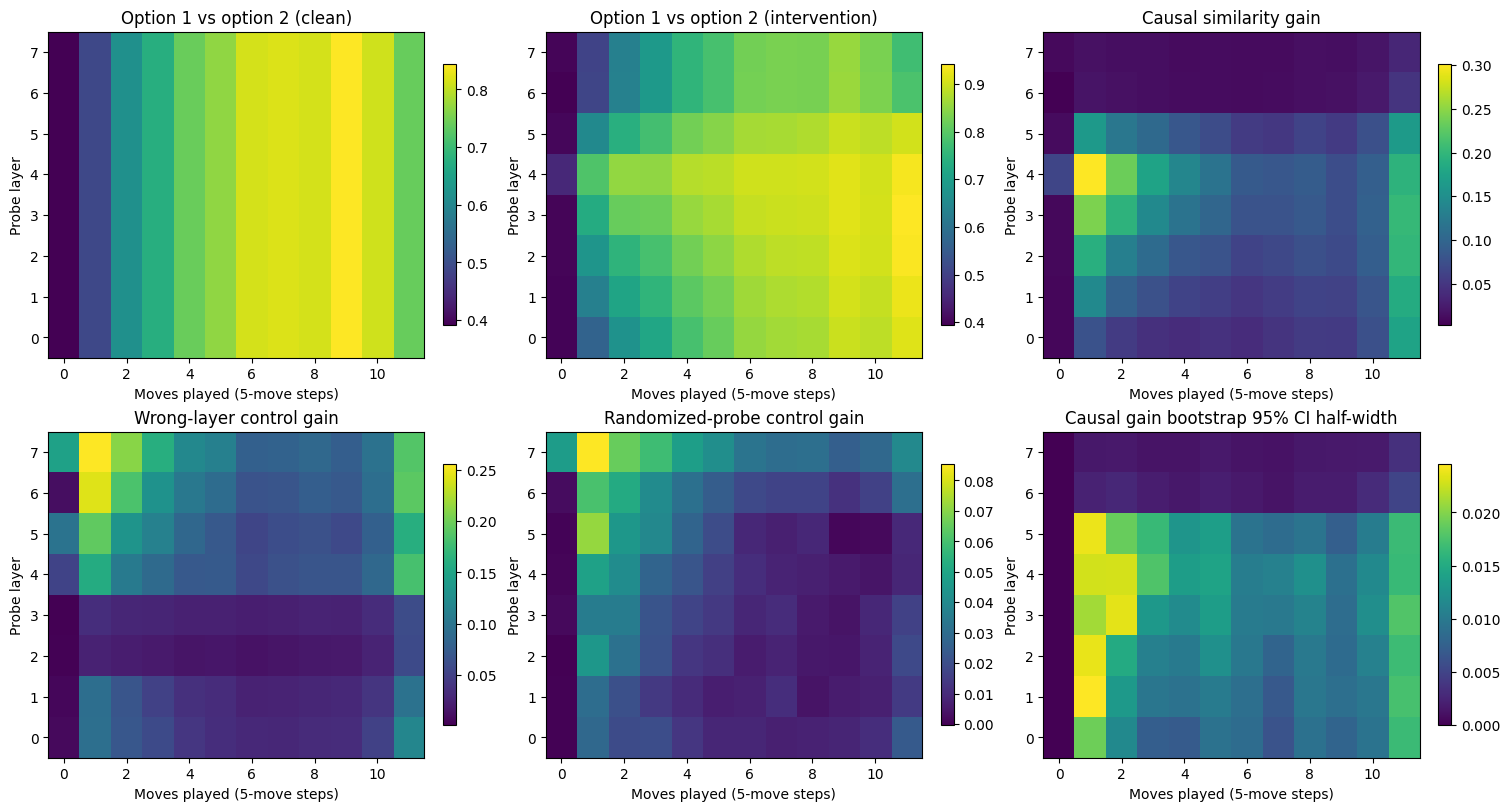

In [5]:
from othello_figure4 import plot_figure4_reproduction, run_figure4_reproduction

figure4_artifact = run_figure4_reproduction(
    cache=CACHE,
    games_int=games_int.detach().cpu().numpy(),
    games_string=games_string,
    othello=othello,
    output_path=Path("../assets/othello-figure4-results.json"),
    number_games=50,
    seed=44,
)
print(
    json.dumps(
        {
            "behavior_and_probe": figure4_artifact["behavior_and_probe"],
            "ordering": figure4_artifact["ordering"],
            "tdhook_reference_parity_max_abs_difference": (
                figure4_artifact["tdhook_reference_parity_max_abs_difference"]
            ),
        },
        indent=2,
    )
)
plot_figure4_reproduction(figure4_artifact)

## Result

The released probes reach 99.22% mean accuracy in layers 6-8, and the model predicts a legal move in 99.93% of 5,800 positions. Across 50 games, the early-game intervention gain in middle layers 3-5 exceeds the gain in layers 7-8 by 0.1300 (paired bootstrap 95% interval 0.1247-0.1360), reproducing the Figure 4 layer ordering for this sample.